# Figure 1: Descriptive Overview of the Perfume Dataset

Panels of Figure 1 plus SI Figures S2-S4, describing the Fragrantica dataset (1900-2024): release trends by type, top perfumers/brands, geographic accord profiles, note/accord frequency heatmaps, and gender targeting.

### Figure 1A: Perfume Count by Type Over Time

Loads the dataset (1900-2024) and assigns each perfume one type by precedence: Luxury > Natural perfumery > Celebrity brand > Niche > Designer > Uncategorized (Luxury and Designer are curated; the rest come from the raw `Type` field). Counts per year per class, plotted on a symlog scale.

Perfume counts by class (1900-2024):
type_class
Uncategorized        29136
Niche                27991
Designer             11366
Luxury                4888
Natural perfumery     1765
Celebrity brand       1340
Total: 76486
(of Luxury, 571 were promoted from an existing Niche designer tag)


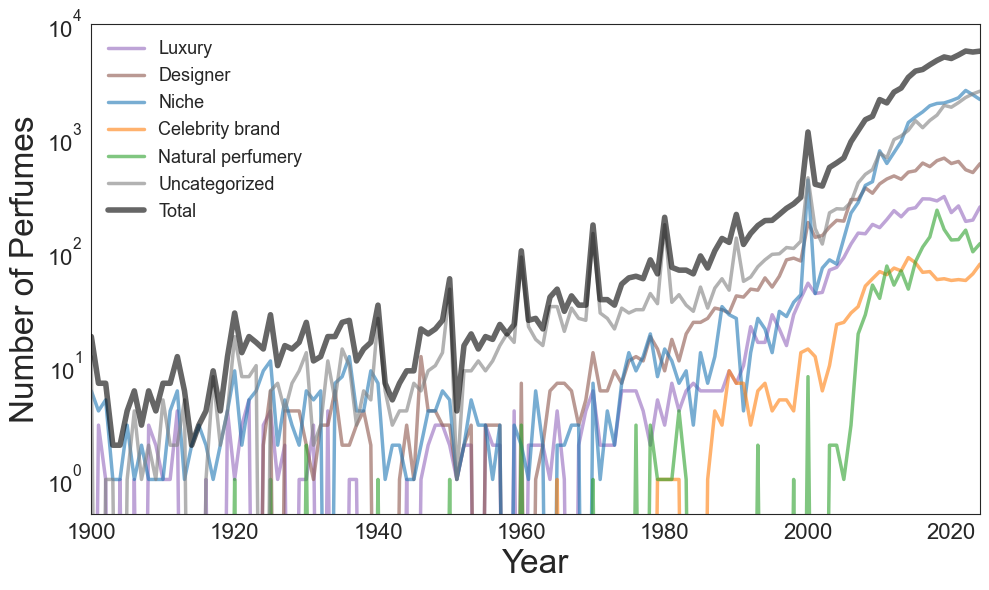

In [1]:
# ===========================================================================
import matplotlib as _mpl
_mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Liberation Sans', 'Bitstream Vera Sans', 'sans-serif'],
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Arial', 'mathtext.it': 'Arial:italic', 'mathtext.bf': 'Arial:bold',
})
# ===========================================================================

import os
import sys
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.colors as mcolors
import seaborn as sns
sys.path.append(os.path.abspath(".."))
from utils.utils import *

# Load and restrict to 1900-2024
data = pd.read_csv("../dataset/Fragrantica.csv")
data['year'] = pd.to_numeric(data['year'], errors='coerce')
data = data.dropna(subset=['year'])
data = data[(data['year'] >= 1900) & (data['year'] <= 2024)]
data['year'] = data['year'].astype(int)

# Curated single-label type (precedence: Luxury > Natural > Celebrity > Niche > Designer > Uncategorized)
LUXURY_HOUSES = {
    'guerlain', 'creed', 'chanel', 'dior', 'hermes', 'givenchy',
    'tom ford', 'yves saint laurent', 'giorgio armani', 'gucci', 'prada',
    'valentino', 'versace', 'bottega veneta', 'dolce gabbana', 'burberry',
    'chloe', 'jean paul gaultier', 'mugler', 'viktor rolf', 'narciso rodriguez',
    'bvlgari', 'cartier', 'tiffany',
    'maison francis kurkdjian', 'byredo', 'le labo', 'frederic malle', 'amouage',
    'xerjoff', 'roja dove', 'clive christian', 'serge lutens', 'penhaligon s',
    'acqua di parma', 'diptyque', 'jo malone london',
}
FASHION_ACTIVITIES = {'Fashion', 'Jewelry', 'Accessories', 'Lingerie', 'Sport Fashion'}

_type  = data['Type'].fillna('').str.strip()
_house = data['brand'].fillna('').astype(str).str.strip().str.lower()
_act   = data['Main Activity'].fillna('').str.strip()

def _classify(type_str, house_l, activity):
    if house_l in LUXURY_HOUSES:         return 'Luxury'
    if 'Natural perfumery' in type_str:  return 'Natural perfumery'
    if 'Celebrity' in type_str:          return 'Celebrity brand'
    if 'Niche designer' in type_str:     return 'Niche'
    if activity in FASHION_ACTIVITIES:   return 'Designer'
    return 'Uncategorized'

data['type_class'] = [_classify(t, h, a) for t, h, a in zip(_type, _house, _act)]

print('Perfume counts by class (1900-2024):')
print(data['type_class'].value_counts().to_string())
print('Total:', len(data))
_promoted = ((data['type_class'] == 'Luxury') & _type.str.contains('Niche designer')).sum()
print(f'(of Luxury, {_promoted} were promoted from an existing Niche designer tag)')

type_counts = (
    data.groupby(['year', 'type_class']).size().reset_index(name='count')
)
df_by_type = type_counts.pivot(index='year', columns='type_class', values='count').fillna(0)

df_total = data.groupby('year').size().rename('Total')
df_combined = df_by_type.join(df_total, how='outer').fillna(0)
df_combined = df_combined.sort_index()

desired_order = [
    "Luxury",
    "Designer",
    "Niche",
    "Celebrity brand",
    "Natural perfumery",
    "Uncategorized",
    "Total",
]

color_map = {
    "Luxury":            "#9467bd",
    "Designer":          "#8c564b",
    "Niche":             "#1f77b4",
    "Celebrity brand":   "#ff7f0e",
    "Natural perfumery": "#2ca02c",
    "Uncategorized":     "#7f7f7f",
    "Total":             "black",
}

final_cols = [col for col in desired_order if col in df_combined.columns]

sns.set_style('white')
plt.figure(figsize=(10, 6))

for col in final_cols:
    if col == 'Total':
        plt.plot(
            df_combined.index, df_combined[col],
            label=col,
            color=color_map[col],
            linewidth=4,
            linestyle='-',
            alpha=0.6,
            zorder=10
        )
    else:
        plt.plot(
            df_combined.index, df_combined[col],
            label=col,
            color=color_map[col],
            linewidth=2.5,
            alpha=0.6
        )

plt.yscale('symlog', linthresh=0.0001)
plt.ylim(0.5, 10000)
plt.xlim(1900, 2024)
plt.xlabel('Year', fontsize=24)
plt.ylabel('Number of Perfumes', fontsize=24)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(title='', bbox_to_anchor=(0, 1), loc='upper left', frameon=False, fontsize=13)
plt.tight_layout()
plt.savefig("../output/Figure_1A.svg", format="svg", dpi=300)
plt.show()

### Figures 1B, 1C: Top 10 Perfumers and Brands

Parses the perfumer and brand columns and plots the ten most prolific of each as horizontal bar charts.

Unique houses: 5144
Unique perfumers: 2349

 Top 10 Perfumers
1. Alberto Morillas: 499 perfumes
2. Olivier Cresp: 401 perfumes
3. Dominique Ropion: 374 perfumes
4. Verônica Kato: 357 perfumes
5. Bertrand Duchaufour: 350 perfumes
6. Nathalie Lorson: 310 perfumes
7. Christian Provenzano: 301 perfumes
8. Chris Maurice: 256 perfumes
9. Francis Kurkdjian: 250 perfumes
10. Jérôme Epinette: 244 perfumes

 Top 10 Houses
1. The Dua Brand: 1584 perfumes
2. Avon: 1012 perfumes
3. Zara: 820 perfumes
4. Victoria s Secret: 739 perfumes
5. Bath Body Works: 558 perfumes
6. Jequiti: 536 perfumes
7. Guerlain: 519 perfumes
8. O Boticario: 504 perfumes
9. Natura: 481 perfumes
10. Oriflame: 373 perfumes


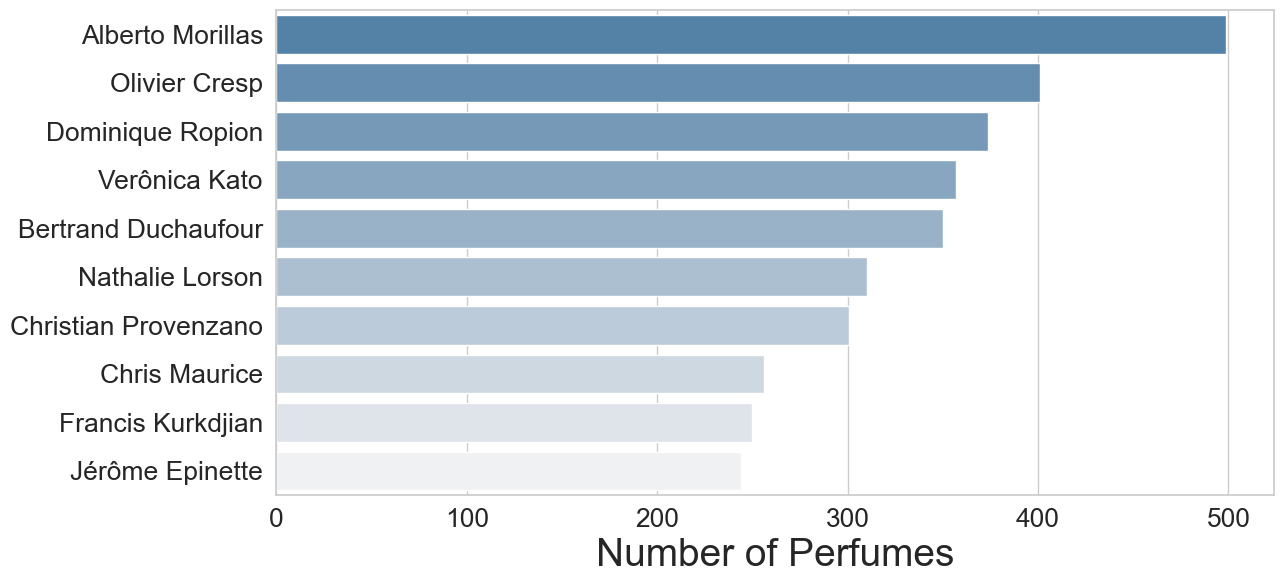

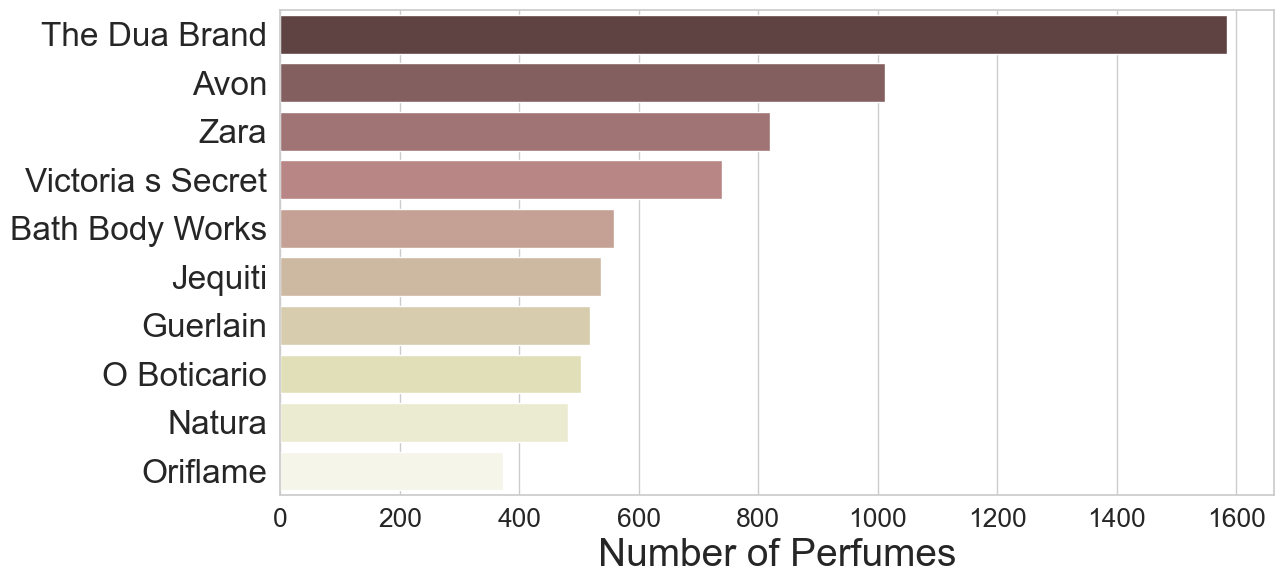

In [2]:
data = pd.read_csv("../dataset/Fragrantica.csv")

# Re-apply the 1900-2024 scope (data was reloaded); reused by the cells below
data['year'] = pd.to_numeric(data['year'], errors='coerce')
data = data.dropna(subset=['year'])
data = data[(data['year'] >= 1900) & (data['year'] <= 2024)]
data['year'] = data['year'].astype(int)

data['perfumer'] = data['perfumer'].apply(parse_perfumer)
data['brand'] = data['brand'].fillna("").apply(lambda x: x.strip())
data['perfumer'] = data.apply(
    lambda r: clean_perfumer_artifacts(r['perfumer'], r['brand']), axis=1
)

perfumer_exploded = data.explode('perfumer')

perfumer_counts = perfumer_exploded['perfumer'].value_counts().head(10)
house_counts = data['brand'].value_counts().head(10)
print("Unique brands:", len(data['brand'].unique()))
print("Unique perfumers:", len(perfumer_exploded['perfumer'].unique()))

print("\n Top 10 Perfumers")
for i, (name, count) in enumerate(perfumer_counts.items(), start=1):
    print(f"{i}. {name}: {count} perfumes")

print("\n Top 10 brands")
for i, (name, count) in enumerate(house_counts.items(), start=1):
    print(f"{i}. {name}: {count} perfumes")

sns.set_theme(style="whitegrid")

plt.figure(figsize=(13, 6))
palette_perfumer = sns.light_palette("steelblue", len(perfumer_counts),reverse=True)
sns.barplot(x=perfumer_counts.values, y=perfumer_counts.index,hue=perfumer_counts.index, palette=palette_perfumer,legend=False)
plt.xlabel('Number of Perfumes', fontsize=28)
plt.ylabel('', fontsize=1)
plt.xticks(fontsize=19)
plt.yticks(fontsize=19)
plt.tight_layout()
plt.savefig("../output/Figure_1B.svg", format="svg", dpi=300)
plt.show()

plt.figure(figsize=(13, 6))
palette_house = sns.color_palette("pink", len(house_counts))
sns.barplot(x=house_counts.values, y=house_counts.index,hue=house_counts.index, palette=palette_house,legend=False)
plt.xlabel('Number of Perfumes', fontsize=28)
plt.ylabel('', fontsize=1)
plt.xticks(fontsize=19)
plt.yticks(fontsize=24)
plt.tight_layout()
plt.savefig("../output/Figure_1C.svg", format="svg", dpi=300)
plt.show()

### Figure 1D: Country Similarity Map by Accord Profile

Per-country accord shares to z-scored log location-quotient features to PCA into 2-D taste space, then colored by position via a cyclic colormap (hue = which accords a country leans toward, paleness = how mainstream). Inset biplot: color = taste position, shape = region, size = market share, arrows = accord loadings. Countries below `MIN_PERFUMES` are hatched.

PCA 2-D captures 33% of the taste variation
PC1:  oud, warm spicy  <-->  green, fresh
PC2:  sweet, fruity  <-->  fresh spicy, aromatic
most distinctive countries: Hong Kong, Bermuda, Croatia, Lithuania, Morocco, Belarus, Oman, Qatar, Armenia, Japan


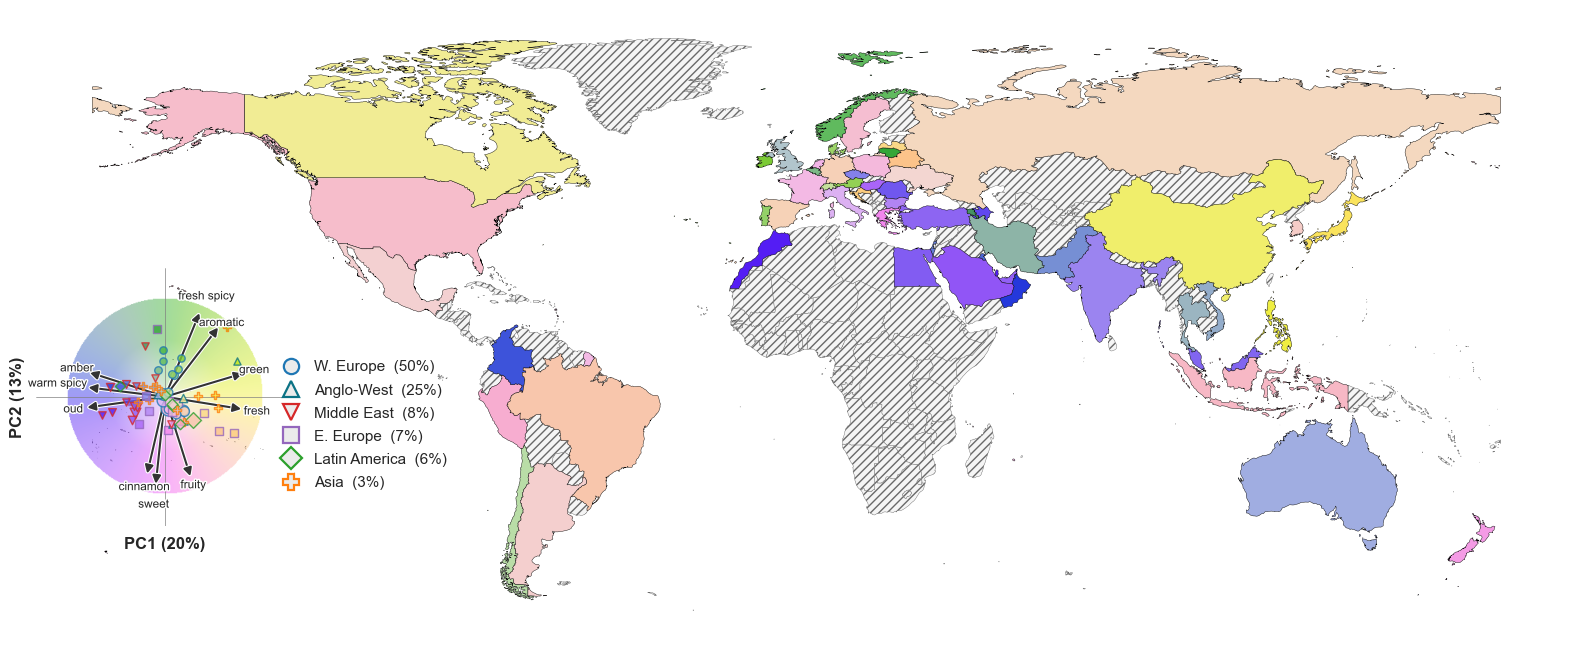

In [3]:
import numpy as np
from collections import defaultdict
from sklearn.decomposition import PCA
import colorcet as cc
import matplotlib.patheffects as pe
import matplotlib.lines as mlines

MIN_PERFUMES = 30
N_FEATURES   = 40

# Standardize country names to the Natural Earth shapefile
country_name_mapping = {
    "United States": "United States of America",
    "St. Barts": "St-Barthélemy",
    "United kingdom": "United Kingdom",
    "Dubai": "United Arab Emirates",
    "Moldavia": "Moldova",
    "Tenerife": "Spain",
    "Dominican Republic": "Dominican Rep.",
    "Czech Republic": "Czechia",
    "Tahiti": "Fr. Polynesia",
    "Wales": "United Kingdom",
}
data["Country"] = data["Country"].replace(country_name_mapping)

# Per-country log location-quotient accord features
acc_lists = data['accords'].apply(parse_accords)
prof = defaultdict(lambda: defaultdict(float))
n_cty = defaultdict(int)
g_cnt = defaultdict(float)
for country, acc in zip(data['Country'], acc_lists):
    if pd.isna(country):
        continue
    n_cty[country] += 1
    for a in acc:
        prof[country][a] += 1
        g_cnt[a] += 1

countries = sorted(c for c in prof if n_cty[c] >= MIN_PERFUMES)
top_acc = [a for a, _ in sorted(g_cnt.items(), key=lambda x: -x[1])[:N_FEATURES]]
g_total = sum(g_cnt.values())
g_share = {a: g_cnt[a] / g_total for a in top_acc}

EPS = 1e-4
M = np.zeros((len(countries), len(top_acc)))
for i, c in enumerate(countries):
    s = sum(prof[c].values())
    for j, a in enumerate(top_acc):
        M[i, j] = np.log((prof[c].get(a, 0) / s + EPS) / (g_share[a] + EPS))
Mz = (M - M.mean(0)) / (M.std(0) + 1e-9)

# PCA into 2-D taste space
pca = PCA(n_components=2)
XY = pca.fit_transform(Mz)
var = pca.explained_variance_ratio_ * 100

# Colour: hue = direction, paleness = how mainstream
CYC = cc.cm.colorwheel
NEUTRAL = np.array([0.93, 0.93, 0.93])
rad   = np.sqrt((XY ** 2).sum(1))
scale = np.percentile(rad, 90)
norm  = XY / scale
rnorm = np.sqrt((norm ** 2).sum(1))
hue   = (np.arctan2(norm[:, 1], norm[:, 0]) + np.pi) / (2 * np.pi)
t     = 0.30 + 0.70 * np.clip(rnorm, 0, 1)
base  = CYC(hue)[:, :3]
rgb   = NEUTRAL * (1 - t)[:, None] + base * t[:, None]
country_hex = {c: mcolors.to_hex(rgb[i]) for i, c in enumerate(countries)}

def _axis_meaning(pc):
    Lc = pca.components_[pc]; o = np.argsort(Lc)
    return (', '.join(top_acc[j] for j in o[:2]),
            ', '.join(top_acc[j] for j in o[::-1][:2]))
pc1_neg, pc1_pos = _axis_meaning(0)
pc2_neg, pc2_pos = _axis_meaning(1)

print(f'PCA 2-D captures {100*pca.explained_variance_ratio_[:2].sum():.0f}% of the taste variation')
print(f'PC1:  {pc1_neg}  <-->  {pc1_pos}')
print(f'PC2:  {pc2_neg}  <-->  {pc2_pos}')
print('most distinctive countries:',
      ', '.join(countries[i] for i in np.argsort(-rad)[:10]))

#coloured by taste-space position
world = (gpd.read_file("../utils/ne_50m_admin_0_countries.shp")
           .query("NAME != 'Antarctica'")
           .explode(index_parts=False)
           .reset_index(drop=True)
           .loc[lambda g: g.is_valid])
world["col"] = world["NAME"].map(country_hex)

fig, ax = plt.subplots(figsize=(16, 10))
world[world["col"].isna()].plot(ax=ax, facecolor="whitesmoke", edgecolor="dimgray",
                                hatch="////", linewidth=0.3, zorder=1)
present = world.dropna(subset=["col"])
present.plot(ax=ax, color=present["col"].values, edgecolor="black", linewidth=0.3, zorder=2)
ax.set_axis_off()

# Biplot inset: region-shaped, market-sized points
REGION_MAP = {**{c: 'W. Europe' for c in ['Austria', 'Belgium', 'Denmark', 'France', 'Germany',
        'Ireland', 'Italy', 'Netherlands', 'Norway', 'Portugal', 'Spain', 'Sweden', 'Switzerland',
        'United Kingdom', 'Monaco']},
    **{c: 'E. Europe' for c in ['Belarus', 'Bulgaria', 'Croatia', 'Czechia', 'Hungary', 'Latvia',
        'Lithuania', 'Poland', 'Romania', 'Russia', 'Ukraine', 'Greece']},
    **{c: 'Anglo-West' for c in ['United States of America', 'Canada', 'Australia', 'New Zealand', 'Bermuda']},
    **{c: 'Latin America' for c in ['Argentina', 'Brazil', 'Chile', 'Colombia', 'Mexico', 'Peru']},
    **{c: 'Middle East' for c in ['Egypt', 'Morocco', 'Turkey', 'Iran', 'Saudi Arabia',
        'United Arab Emirates', 'Kuwait', 'Qatar', 'Bahrain', 'Oman', 'Israel', 'Armenia', 'Azerbaijan']},
    **{c: 'Asia' for c in ['India', 'Pakistan', 'China', 'Japan', 'South Korea', 'Hong Kong',
        'Indonesia', 'Malaysia', 'Philippines', 'Singapore', 'Thailand', 'Vietnam']}}
REGION_MARKER = {'W. Europe': 'o', 'E. Europe': 's', 'Anglo-West': '^',
                 'Latin America': 'D', 'Middle East': 'v', 'Asia': 'P', 'Other': 'X'}
REGION_EDGE = {'W. Europe': '#1f77b4', 'E. Europe': '#9467bd', 'Anglo-West': '#0b7285',
               'Latin America': '#2ca02c', 'Middle East': '#d62728', 'Asia': '#ff7f0e', 'Other': '#555555'}
reg = np.array([REGION_MAP.get(c, 'Other') for c in countries], dtype=object)

# Marker size encodes the country's market share
frac = np.array([n_cty[c] for c in countries], dtype=float)
frac = frac / frac.sum()
sizes = 25 + (frac / frac.max()) ** 0.6 * 95

axin = ax.inset_axes([0.0, 0.18, 0.185, 0.41])
axin.set_facecolor('none')
ext = max(1.3, rnorm.max() * 1.05)
_halo = [pe.withStroke(linewidth=2.0, foreground='white')]

_gnw = 260
_gxw, _gyw = np.meshgrid(np.linspace(-ext, ext, _gnw), np.linspace(-ext, ext, _gnw))
_grw = np.sqrt(_gxw ** 2 + _gyw ** 2)
_gaw = (np.arctan2(_gyw, _gxw) + np.pi) / (2 * np.pi)
_twd = 0.30 + 0.70 * np.clip(_grw, 0, 1)
_wheel = NEUTRAL * (1 - _twd)[..., None] + CYC(_gaw)[..., :3] * _twd[..., None]
_wheel[_grw > ext] = 1.0
axin.imshow(_wheel, extent=[-ext, ext, -ext, ext], origin="lower", zorder=0, alpha=0.45)

# Accord loading arrows with labels
_topL = list(np.argsort(-np.hypot(pca.components_[0], pca.components_[1]))[:10])
_ek = 0.92 * ext / np.abs(pca.components_[:, _topL]).max()
_angs = {j: np.arctan2(pca.components_[1, j], pca.components_[0, j]) for j in _topL}
_placed = []
_lab_r = {}
for j in sorted(_topL, key=lambda j: _angs[j]):
    a = _angs[j]; r = 0.95
    while any(abs((a - pa + np.pi) % (2 * np.pi) - np.pi) < 0.34 and abs(r - pr) < 0.16
             for pa, pr in _placed):
        r += 0.01
    _placed.append((a, r)); _lab_r[j] = r
for j in _topL:
    _cx, _cy = pca.components_[0, j], pca.components_[1, j]
    _nn = np.hypot(_cx, _cy) or 1.0
    _an = axin.annotate('', xy=(_cx * _ek, _cy * _ek), xytext=(0, 0),
                        arrowprops=dict(arrowstyle='-|>', color='#333333', lw=1.5), zorder=5)
    _an.arrow_patch.set_path_effects([pe.withStroke(linewidth=3.0, foreground='white')])
    axin.text(_cx / _nn * ext * _lab_r[j], _cy / _nn * ext * _lab_r[j], top_acc[j], fontsize=8.5,
              ha='center', va='center', zorder=7, clip_on=False, path_effects=_halo)

for i in np.argsort(-sizes):
    axin.scatter(norm[i, 0], norm[i, 1], marker=REGION_MARKER[reg[i]], s=sizes[i],
                 c=[country_hex[countries[i]]], edgecolor=REGION_EDGE[reg[i]],
                 linewidth=1.0, alpha=0.8, zorder=6)

axin.axhline(0, color="gray", lw=0.5, zorder=1)
axin.axvline(0, color="gray", lw=0.5, zorder=1)
axin.set_xlabel(f'PC1 ({var[0]:.0f}%)', fontsize=12, fontweight='bold', labelpad=8)
axin.set_ylabel(f'PC2 ({var[1]:.0f}%)', fontsize=12, fontweight='bold', labelpad=8)
axin.set_xticks([]); axin.set_yticks([])
axin.set_xlim(-ext * 1.32, ext * 1.32); axin.set_ylim(-ext * 1.32, ext * 1.32)
for _s in axin.spines.values():
    _s.set_visible(False)

# Legend: regions by market share
_rshare = {r: frac[reg == r].sum() for r in REGION_MARKER if (reg == r).any()}
_rsorted = sorted(_rshare, key=_rshare.get, reverse=True)
_reg_handles = [mlines.Line2D([], [], marker=REGION_MARKER[r], linestyle='None',
                              markerfacecolor='0.92', markeredgecolor=REGION_EDGE[r],
                              markeredgewidth=1.6, markersize=11, label=f'{r}  ({_rshare[r]*100:.0f}%)')
                for r in _rsorted]
ax.legend(handles=_reg_handles, loc='center left', bbox_to_anchor=(0.16, 0.34),
          fontsize=11, frameon=False, labelspacing=0.6, handletextpad=0.5, borderaxespad=0.0)

plt.tight_layout()
plt.savefig("../output/Figure_1D.svg", format="svg", dpi=300)
plt.show()

### Figure 1E: Top-50 Notes Frequency Heatmap

Within-year frequency of the 50 most common notes across time, log-scaled.

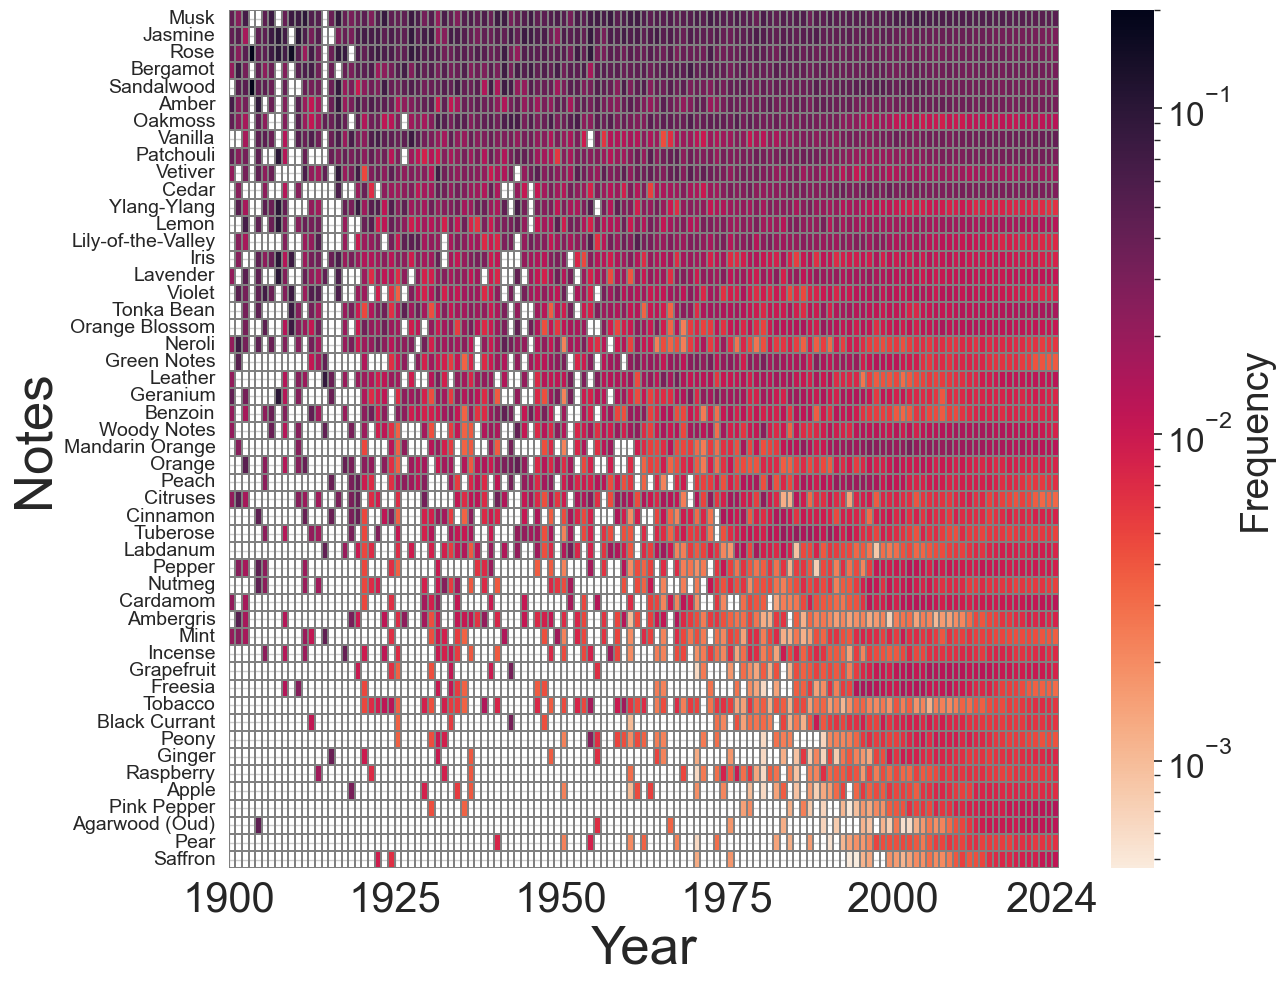

In [4]:
data['note_list'] = data['notes'].apply(parse_notes)

rows = [{'year': row.year, 'note': n}
        for _, row in data.iterrows()
        for n in row.note_list]

exploded = pd.DataFrame(rows)

# Count notes, normalize to within-year frequency
note_counts = exploded.groupby(['year', 'note']).size().reset_index(name='count')
note_counts['percentage'] = note_counts['count'] / note_counts.groupby('year')['count'].transform('sum')

# Keep top-50 notes
top_notes = (note_counts.groupby('note')['count']
                       .sum()
                       .nlargest(50)
                       .index)
filtered = note_counts[note_counts['note'].isin(top_notes)]
pivot = (filtered.pivot(index='note', columns='year', values='percentage')
                   .fillna(0))
pivot['total'] = pivot.sum(axis=1)
pivot = pivot.sort_values('total', ascending=False).drop(columns='total')

desired_years = [1900, 1925, 1950, 1975, 2000, 2024]
for y in desired_years:
    if y not in pivot.columns:
        pivot[y] = 0
pivot = pivot.reindex(sorted(pivot.columns), axis=1)
year_positions = [i for i, y in enumerate(pivot.columns) if y in desired_years]

plt.figure(figsize=(13, 10))
ax = sns.heatmap(
    pivot,
    cmap='rocket_r',
    norm=mcolors.LogNorm(vmin=pivot.replace(0, float('nan')).min().min(),
                         vmax=pivot.max().max()),
    cbar_kws={'label': 'Frequency'},
    linewidths=0.05,
    linecolor='gray',
    yticklabels=pivot.index
)
cbar = ax.collections[0].colorbar
cbar.set_label('Frequency', fontsize=28)
cbar.ax.tick_params(labelsize=24)

plt.xlabel('Year', fontsize=38)
plt.ylabel('Notes', fontsize=38)
plt.xticks(ticks=year_positions, labels=desired_years, rotation=0, fontsize=30)
plt.yticks(rotation=0, fontsize=14)
plt.tight_layout()
plt.savefig("../output/Figure_1E.svg", format="svg", dpi=300)
plt.show()

### Figure 1F: Top-50 Accords Frequency Heatmap

Same as Figure 1E, for accords.

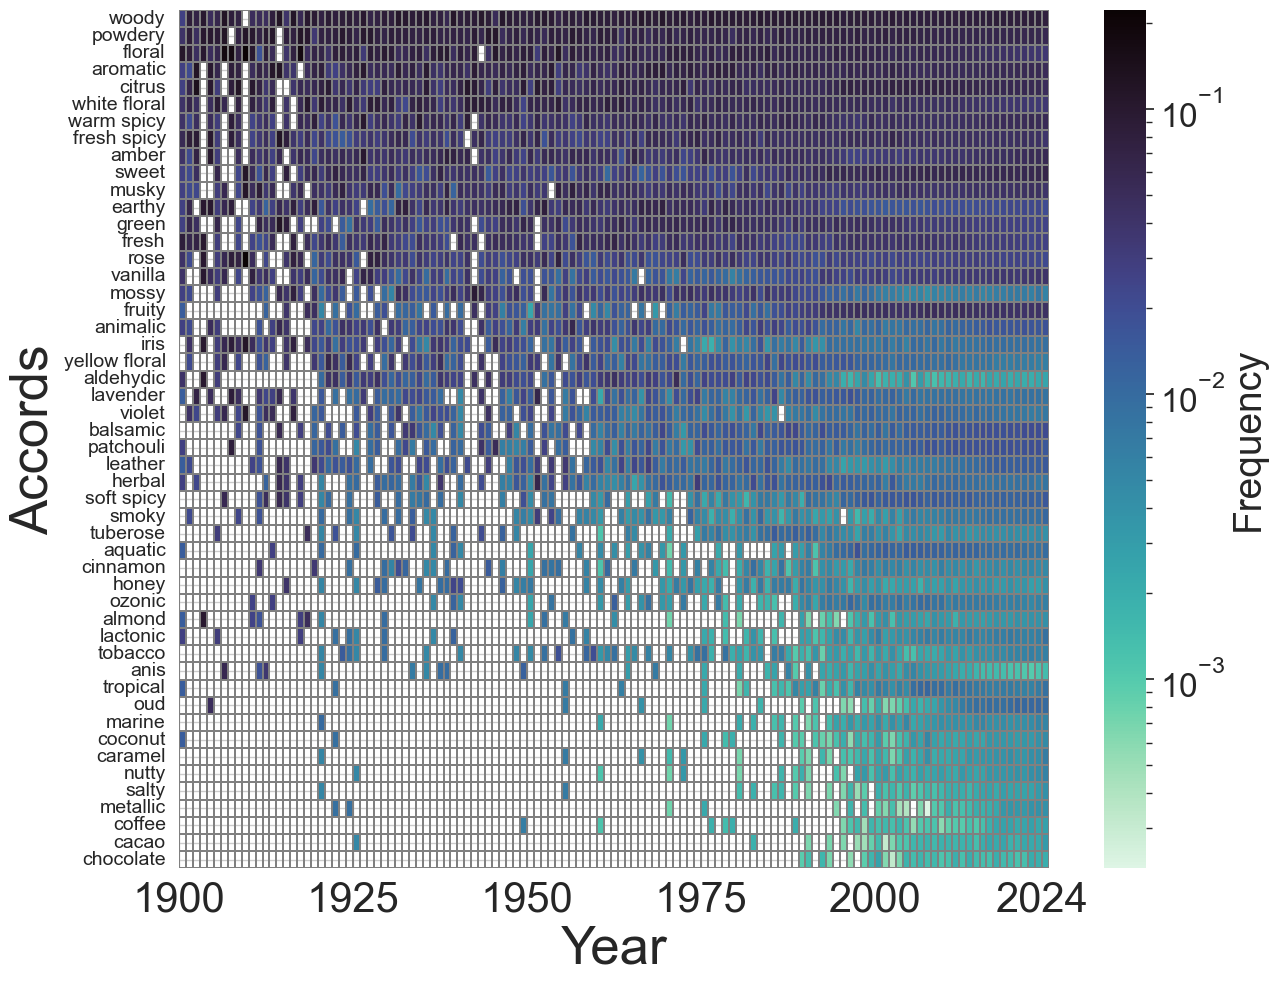

In [5]:
data['accord_list'] = data['accords'].apply(parse_accords)

rows = [{'year': row.year, 'accord': acc}
        for _, row in data.iterrows()
        for acc in row.accord_list]

exploded = pd.DataFrame(rows)

# Count accords, normalize to within-year frequency
acc_counts = exploded.groupby(['year', 'accord']).size().reset_index(name='count')
acc_counts['percentage'] = acc_counts['count'] / acc_counts.groupby('year')['count'].transform('sum')

# Keep top-50 accords
top_acc = (acc_counts.groupby('accord')['count']
                      .sum()
                      .nlargest(50)
                      .index)
filtered = acc_counts[acc_counts['accord'].isin(top_acc)]
pivot = (filtered.pivot(index='accord', columns='year', values='percentage')
                   .fillna(0))
pivot['total'] = pivot.sum(axis=1)
pivot = pivot.sort_values('total', ascending=False).drop(columns='total')

desired_years = [1900, 1925, 1950, 1975, 2000, 2024]
for y in desired_years:
    if y not in pivot.columns:
        pivot[y] = 0
pivot = pivot.reindex(sorted(pivot.columns), axis=1)
year_positions = [i for i, y in enumerate(pivot.columns) if y in desired_years]

plt.figure(figsize=(13, 10))
ax = sns.heatmap(
    pivot,
    cmap='mako_r',
    norm=mcolors.LogNorm(vmin=pivot.replace(0, float('nan')).min().min(),
                         vmax=pivot.max().max()),
    cbar_kws={'label': 'Frequency (log scale)'},
    linewidths=0.05,
    linecolor='gray',
    yticklabels=pivot.index
)
cbar = ax.collections[0].colorbar
cbar.set_label('Frequency', fontsize=28)
cbar.ax.tick_params(labelsize=24)

plt.xlabel('Year', fontsize=38)
plt.ylabel('Accords', fontsize=38)
plt.xticks(ticks=year_positions, labels=desired_years, rotation=0, fontsize=30)
plt.yticks(rotation=0, fontsize=14)
plt.tight_layout()
plt.savefig("../output/Figure_1F.svg", format="svg", dpi=300)
plt.show()

### Check: exploded accords table

Quick inspection of the exploded accord rows.

In [6]:
print(exploded.columns.tolist())
print(exploded.head())


['year', 'accord']
   year      accord
0  2022       woody
1  2022       amber
2  2022  warm spicy
3  2022     vanilla
4  2022     powdery


### Figure 1G: Gender Share Over Time

Standardizes gender into Men/Women/Unisex and plots yearly market share as a stacked area chart.

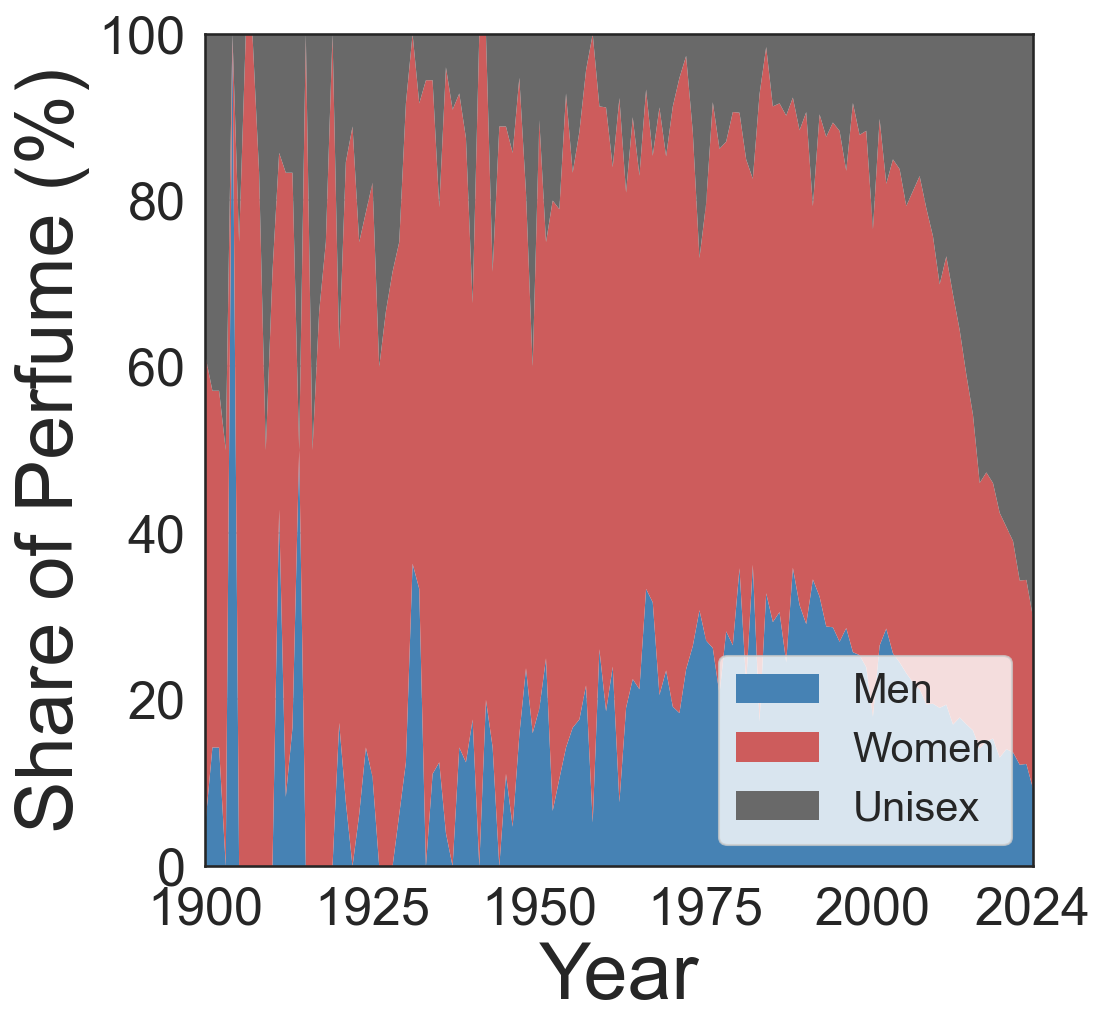

In [7]:
MIN_YEAR, MAX_YEAR = 1900, 2024
TICKS         = [1900, 1925, 1950, 1975, 2000, 2024]

# Standardize gender categories
label_map = {
    "male":   "Men",    "men": "Men",    "m": "Men",
    "female": "Women",  "women": "Women","f": "Women",
    "unisex": "Unisex", "shared": "Unisex",
}
data["gender_std"] = (
    data["gender"].str.lower().map(label_map).fillna(data["gender"])
)

counts = (data.groupby(["year", "gender_std"]).size().reset_index(name="count"))

counts["percentage"] = (
    counts["count"] /
    counts.groupby("year")["count"].transform("sum")
) * 100

years   = counts["year"].unique()
genders = ["Men", "Women", "Unisex"]

counts = (counts.set_index(["year", "gender_std"])
                 .reindex(pd.MultiIndex.from_product([years, genders],
                                                     names=["year", "gender_std"]),
                          fill_value=0)
                 .reset_index())

pivot = (counts.pivot(index="year",
                      columns="gender_std",
                      values="percentage")
               .fillna(0)
               .sort_index())

# Stacked area plot
sns.set_style("whitegrid", {"axes.edgecolor": "0.15"})
plt.rcParams.update({
    "figure.dpi":     150,
    "savefig.dpi":    300,
    "font.size":      11,
    "axes.titlesize": 13,
    "axes.labelsize": 25,
    "xtick.labelsize":15,
    "ytick.labelsize":15,
    "legend.fontsize":11,
    "lines.antialiased": True,
})

palette = {
    "Men":    "steelblue",
    "Women":  "indianred",
    "Unisex": "dimgray",
}

fig, ax = plt.subplots(figsize=(7.5, 7))
pivot[genders].plot.area(
    stacked=True,
    linewidth=0,
    color=[palette[g] for g in genders],
    ax=ax,
)

ax.set_ylim(0, 100)
ax.set_xlim(MIN_YEAR, MAX_YEAR)
ax.set_ylabel("Share of Perfume (%)", fontsize=38)
ax.set_xlabel("Year", fontsize=38)
ax.set_xticks(ticks=TICKS)
ax.set_xticklabels(TICKS, rotation=0, fontsize=25)
ax.tick_params(axis='y', labelsize=25)

ax.legend(title="", frameon=True, loc="lower right", fontsize=20)
plt.tight_layout()
plt.savefig("../output/Figure_1G.svg", format="svg", dpi=300)
plt.show()

### Figure S2: Growth of Perfume Releases (Two Waves)

Cumulative perfume count per year (1800-2024) fit with a double-logistic and a piecewise-Richards model. Marks the two growth waves, their inflection years, carrying capacities, and a data-driven stagnation window separating Classic from Industrial perfumery.

=== Double Logistic (All Data) ===
A=1.001, K1=20.000, r1=0.1241, t1=1917.64, K2=6561.040, r2=0.2183, t2=2013.96

=== Richards Piecewise ===
Wave 1 => A=1.010, K=20.000, r=0.10000, t0=1918.473, nu=0.873
Wave 2 => A=20.000, K=5688.615, r=0.57937, t0=2017.781, nu=0.250

1st carrying capacity range ~ 20-21
2nd carrying capacity range ~ 5689-6582
1st inflection range        ~ 1918
2nd inflection range        ~ 2014-2018
Data-driven stagnation window: 1926-1979


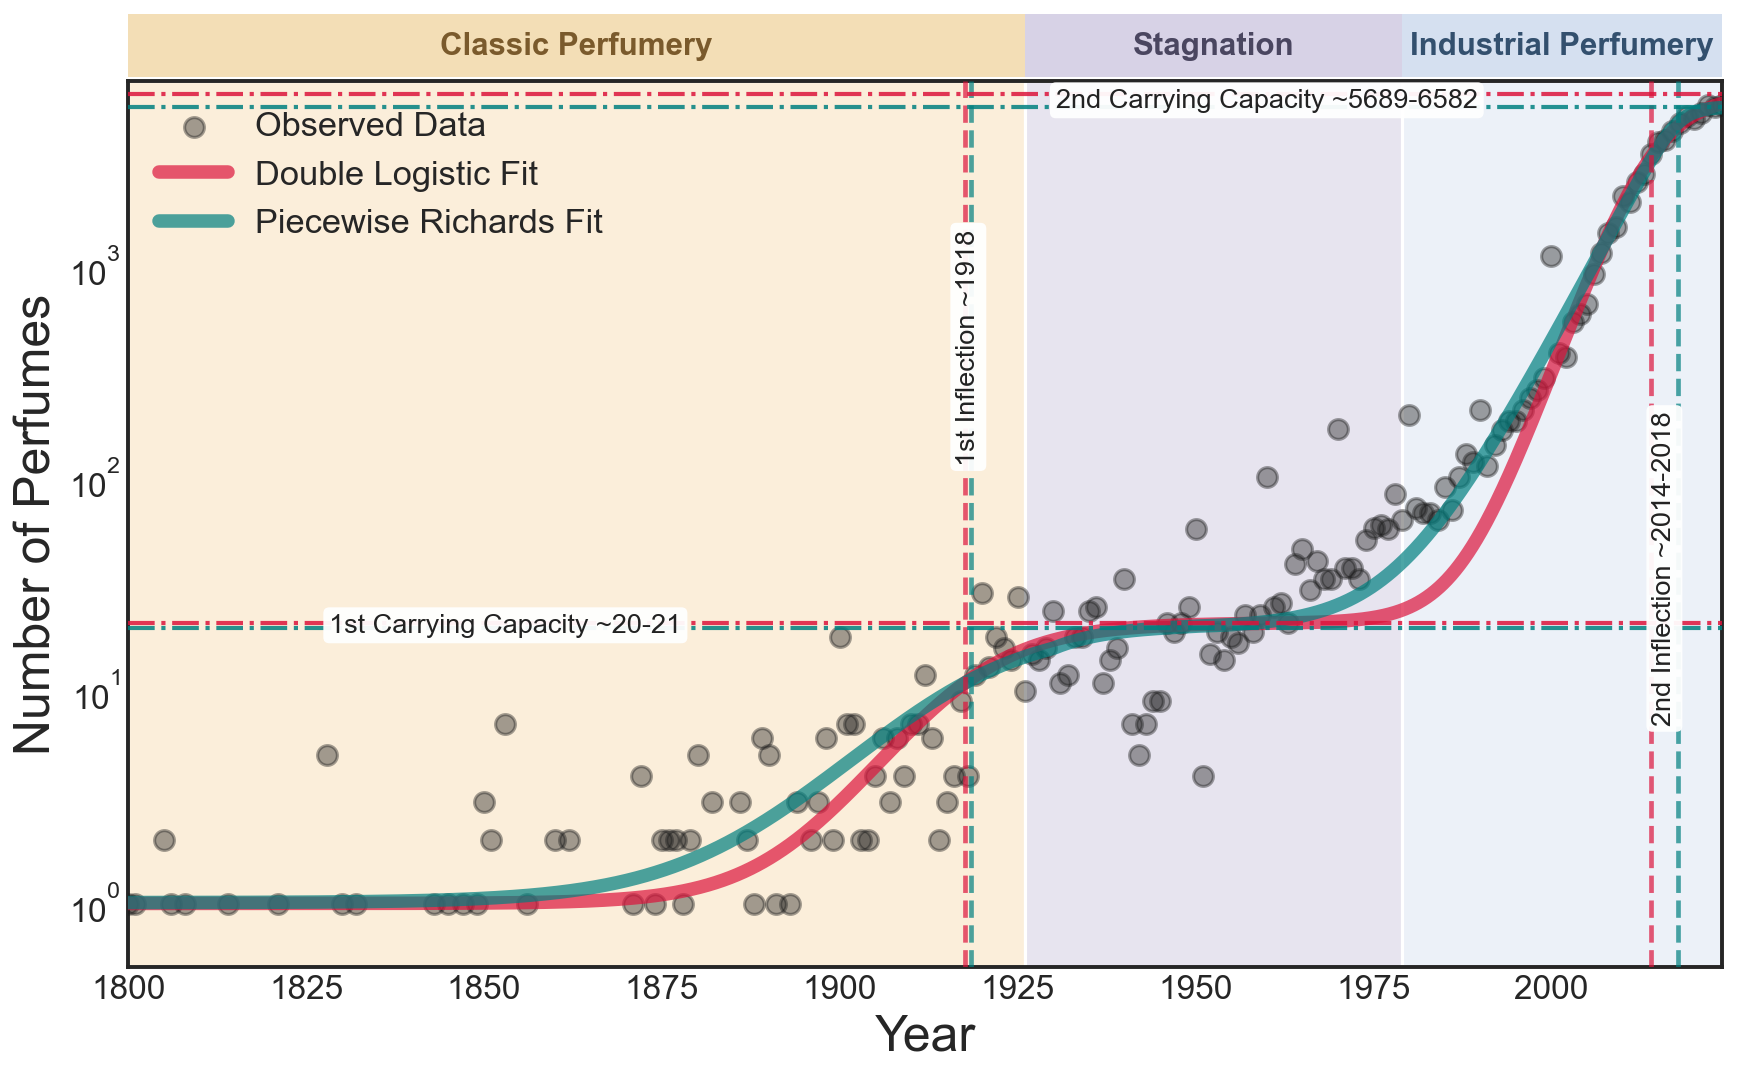

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
from matplotlib.patches import Rectangle
from scipy.optimize import curve_fit
from statsmodels.nonparametric.smoothers_lowess import lowess
import seaborn as sns

# Perfume totals per year (1800-2024)
sns.set_style('white')
sns.set_context('talk')
sns.set_palette('Set2')

df = pd.read_csv("../dataset/Fragrantica.csv")
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df = df.dropna(subset=['year'])
df = df[(df['year'] >= 1800) & (df['year'] <= 2024)]
df['year'] = df['year'].astype(int)

if 'Total' not in df.columns:
    df_total = df.groupby('year').size().rename('Total').reset_index().set_index('year')
else:
    df_total = df.set_index('year')[['Total']]

t_data = df_total.index.to_numpy(dtype=float)
N_data = df_total['Total'].to_numpy(dtype=float)

sort_idx = np.argsort(t_data)
t_data_sorted = t_data[sort_idx]
N_data_sorted = N_data[sort_idx]

# Double logistic (free lower limit) fit on all data
def double_logistic_lower(t, A, K1, r1, t1, K2, r2, t2):
    term1 = K1 / (1.0 + np.exp(-r1*(t - t1)))
    term2 = K2 / (1.0 + np.exp(-r2*(t - t2)))
    return A + term1 + term2

A_guess  = 1.0
K1_guess = 20
r1_guess = 0.1
t1_guess = 1920
K2_guess = 60000
r2_guess = 0.5
t2_guess = 1950

p0_double = [A_guess, K1_guess, r1_guess, t1_guess, K2_guess, r2_guess, t2_guess]

lower_bounds_double = [1,     19.99,  0,   1910,   0,    0,   1900]
upper_bounds_double = [1.001, 20,     2,   1930, 1e6,    2,   2124]

params_double, _ = curve_fit(
    double_logistic_lower,
    t_data_sorted,
    N_data_sorted,
    p0=p0_double,
    bounds=(lower_bounds_double, upper_bounds_double),
    maxfev=20000
)
A_fit, K1_fit, r1_fit, t1_fit, K2_fit, r2_fit, t2_fit = params_double

# Piecewise Richards: wave 1 (1800-1950) and wave 2 (1930-2024)
mask_wave1 = (t_data_sorted >= 1800) & (t_data_sorted <= 1950)
mask_wave2 = (t_data_sorted >= 1930) & (t_data_sorted <= 2024)

t_wave1 = t_data_sorted[mask_wave1]
N_wave1 = N_data_sorted[mask_wave1]
t_wave2 = t_data_sorted[mask_wave2]
N_wave2 = N_data_sorted[mask_wave2]

def richards(t, A, K, r, t0, nu):
    return A + (K - A) / (1.0 + np.exp(-r * (t - t0)))**nu

p0_rich1 = [1, 20, 0.01, 1900, 1.0]
bounds_rich1 = ([1, 10, 0.001, 1850, 0.5],
                [1.01, 20, 0.1, 1950, 5])
params_rich1, _ = curve_fit(richards, t_wave1, N_wave1, p0=p0_rich1,
                            bounds=bounds_rich1, maxfev=10000)
A1, K1, r1, t01, nu1 = params_rich1

p0_rich2 = [20, 6000, 0.01, 1960, 0.0]
bounds_rich2 = ([10, 3000, 0.001, 1930, 0],
                [20, 700000, 1, 2050, 0.25])
params_rich2, _ = curve_fit(richards, t_wave2, N_wave2, p0=p0_rich2,
                            bounds=bounds_rich2, maxfev=10000)
A2, K2, r2, t02, nu2 = params_rich2

T_low = 1930
T_high = 1950
def piecewise_richards(t):
    t = np.asarray(t)
    y = np.zeros_like(t)
    mask1 = t < T_low
    mask2 = t > T_high
    mask_blend = (t >= T_low) & (t <= T_high)

    y[mask1] = richards(t[mask1], A1, K1, r1, t01, nu1)
    y[mask2] = richards(t[mask2], A2, K2, r2, t02, nu2)

    if np.any(mask_blend):
        w = (t[mask_blend] - T_low) / (T_high - T_low)
        y1 = richards(t[mask_blend], A1, K1, r1, t01, nu1)
        y2 = richards(t[mask_blend], A2, K2, r2, t02, nu2)
        y[mask_blend] = (1 - w)*y1 + w*y2
    return y

# Carrying capacities and inflection labels
cap1_dl = A_fit + K1_fit
cap2_dl = A_fit + K1_fit + K2_fit
cap1_ri = K1
cap2_ri = K2

def _rng(a, b, sep="-"):
    lo, hi = sorted([int(round(a)), int(round(b))])
    return f"{lo}" if lo == hi else f"{lo}{sep}{hi}"

inf1_label = _rng(t1_fit, t01)
inf2_label = _rng(t2_fit, t02)
cap1_label = _rng(cap1_dl, cap1_ri)
cap2_label = _rng(cap2_dl, cap2_ri)

# Stagnation window: span between inflections where log-growth drops below 15% of its peak
t_grid   = np.linspace(t_data_sorted.min(), t_data_sorted.max(), 5000)
N_grid   = double_logistic_lower(t_grid, *params_double)
log_rate = np.gradient(np.log(N_grid), t_grid)
between  = (t_grid >= t1_fit) & (t_grid <= t2_fit)
stag_sel = between & (log_rate < 0.15 * log_rate.max())
stag_start = int(round(t_grid[stag_sel].min()))
stag_end   = int(round(t_grid[stag_sel].max()))

print("=== Double Logistic (All Data) ===")
print(f"A={A_fit:.3f}, K1={K1_fit:.3f}, r1={r1_fit:.4f}, t1={t1_fit:.2f}, "
      f"K2={K2_fit:.3f}, r2={r2_fit:.4f}, t2={t2_fit:.2f}")

print("\n=== Richards Piecewise ===")
print(f"Wave 1 => A={A1:.3f}, K={K1:.3f}, r={r1:.5f}, t0={t01:.3f}, nu={nu1:.3f}")
print(f"Wave 2 => A={A2:.3f}, K={K2:.3f}, r={r2:.5f}, t0={t02:.3f}, nu={nu2:.3f}")

print(f"\n1st carrying capacity range ~ {cap1_label}")
print(f"2nd carrying capacity range ~ {cap2_label}")
print(f"1st inflection range        ~ {inf1_label}")
print(f"2nd inflection range        ~ {inf2_label}")
print(f"Data-driven stagnation window: {stag_start}-{stag_end}")

# Plot data + both fits with era background bands
t_fine = np.linspace(t_data_sorted.min(), t_data_sorted.max(), 3000)
N_double = double_logistic_lower(t_fine, *params_double)
N_richards_piecewise = piecewise_richards(t_fine)

fig, ax = plt.subplots(figsize=(12, 7.5))

ax.set_yscale('symlog', linthresh=0.0001)
ax.set_ylim(0.5, 1.3 * max(N_data_sorted))
ax.set_xlim(1800, 2024)

classic_fc, classic_hc, classic_tc = '#FBEEDA', '#F3DEB6', '#7A5A2C'
stag_fc,    stag_hc,    stag_tc    = '#E7E4EF', '#D7D2E6', '#4A4660'
indus_fc,   indus_hc,   indus_tc   = '#ECF1F8', '#D5E0F0', '#33506E'

ax.axvspan(1800,       stag_start, facecolor=classic_fc, zorder=0)
ax.axvspan(stag_start, stag_end,   facecolor=stag_fc,    zorder=0)
ax.axvspan(stag_end,   2024,       facecolor=indus_fc,   zorder=0)

blend = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)

label_bbox = dict(boxstyle='round,pad=0.22', facecolor='white',
                  alpha=0.95, edgecolor='none')

bands = [("Classic Perfumery",   1800,       stag_start, classic_hc, classic_tc),
         ("Stagnation",          stag_start, stag_end,   stag_hc,    stag_tc),
         ("Industrial Perfumery", stag_end,   2024,       indus_hc,   indus_tc)]
for name, x0, x1, hc, tc in bands:
    ax.add_patch(Rectangle((x0, 1.005), x1 - x0, 0.07, transform=blend,
                           facecolor=hc, edgecolor='none', clip_on=False, zorder=2))
    ax.text((x0 + x1) / 2, 1.04, name, transform=blend, ha='center', va='center',
            fontsize=15, fontweight='bold', color=tc, clip_on=False, zorder=3)

ax.scatter(t_data_sorted, N_data_sorted, color='k', s=90, alpha=0.4,
           label='Observed Data', zorder=3)

double_color = 'crimson'
ax.plot(t_fine, N_double, color=double_color, lw=6.5, alpha=0.7,
        label='Double Logistic Fit', zorder=4)

richards_color = 'teal'
ax.plot(t_fine, N_richards_piecewise, color=richards_color, lw=6.5, alpha=0.7,
        label='Piecewise Richards Fit', zorder=4)

ax.axvline(x=t1_fit, color=double_color, linestyle='--', alpha=0.7, zorder=4)
ax.axvline(x=t2_fit, color=double_color, linestyle='--', alpha=0.7, zorder=4)
ax.axvline(x=t01, color=richards_color, linestyle='--', alpha=0.7, zorder=4)
ax.axvline(x=t02, color=richards_color, linestyle='--', alpha=0.7, zorder=4)

ax.text((t1_fit + t01) / 2, 0.70, f"1st Inflection ~{inf1_label}", transform=blend,
        rotation=90, va='center', ha='center', fontsize=13, color='#222',
        zorder=7, bbox=label_bbox)
ax.text((t2_fit + t02) / 2, 0.45, f"2nd Inflection ~{inf2_label}", transform=blend,
        rotation=90, va='center', ha='center', fontsize=13, color='#222',
        zorder=7, bbox=label_bbox)

cap_ls = '-.'
ax.axhline(cap1_dl, color=double_color,   linestyle=cap_ls, lw=2, alpha=0.85, zorder=4)
ax.axhline(cap2_dl, color=double_color,   linestyle=cap_ls, lw=2, alpha=0.85, zorder=4)
ax.axhline(cap1_ri, color=richards_color, linestyle=cap_ls, lw=2, alpha=0.85, zorder=4)
ax.axhline(cap2_ri, color=richards_color, linestyle=cap_ls, lw=2, alpha=0.85, zorder=4)

ax.text(1853, np.sqrt(cap1_dl * cap1_ri), f"1st Carrying Capacity ~{cap1_label}",
        ha='center', va='center', fontsize=13, color='#222', zorder=7, bbox=label_bbox)
ax.text(1960, np.sqrt(cap2_dl * cap2_ri), f"2nd Carrying Capacity ~{cap2_label}",
        ha='center', va='center', fontsize=13, color='#222', zorder=7, bbox=label_bbox)

ax.tick_params(axis='both', which='major', direction='in', length=8, width=1.5)
ax.tick_params(axis='both', which='minor', direction='in', length=4, width=1.0)

ax.set_xlabel('Year', fontsize=24)
ax.set_ylabel('Number of Perfumes', fontsize=24)
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)

ax.legend(frameon=False, loc='upper left')
fig.tight_layout()
fig.savefig("../output/Figure_S2.pdf", format="pdf", dpi=300, bbox_inches='tight')

plt.show()

### Figure S3: Regional Signatures of Scent

Mean per-region profile (z-scored log location-quotient) for notes (A) and accords (B), drawn on radar axes (the top-10 PCA-loading items). PERMANOVA reports the share of profile variance explained by geographic region (pseudo-R^2, p).

Accords: region explains 17% of profile variance (raw R^2=0.173, adj R^2=0.101, pseudo-F=2.39, p=0.001).
Notes:   region explains 13% of profile variance (raw R^2=0.126, adj R^2=0.049, pseudo-F=1.64, p=0.002).


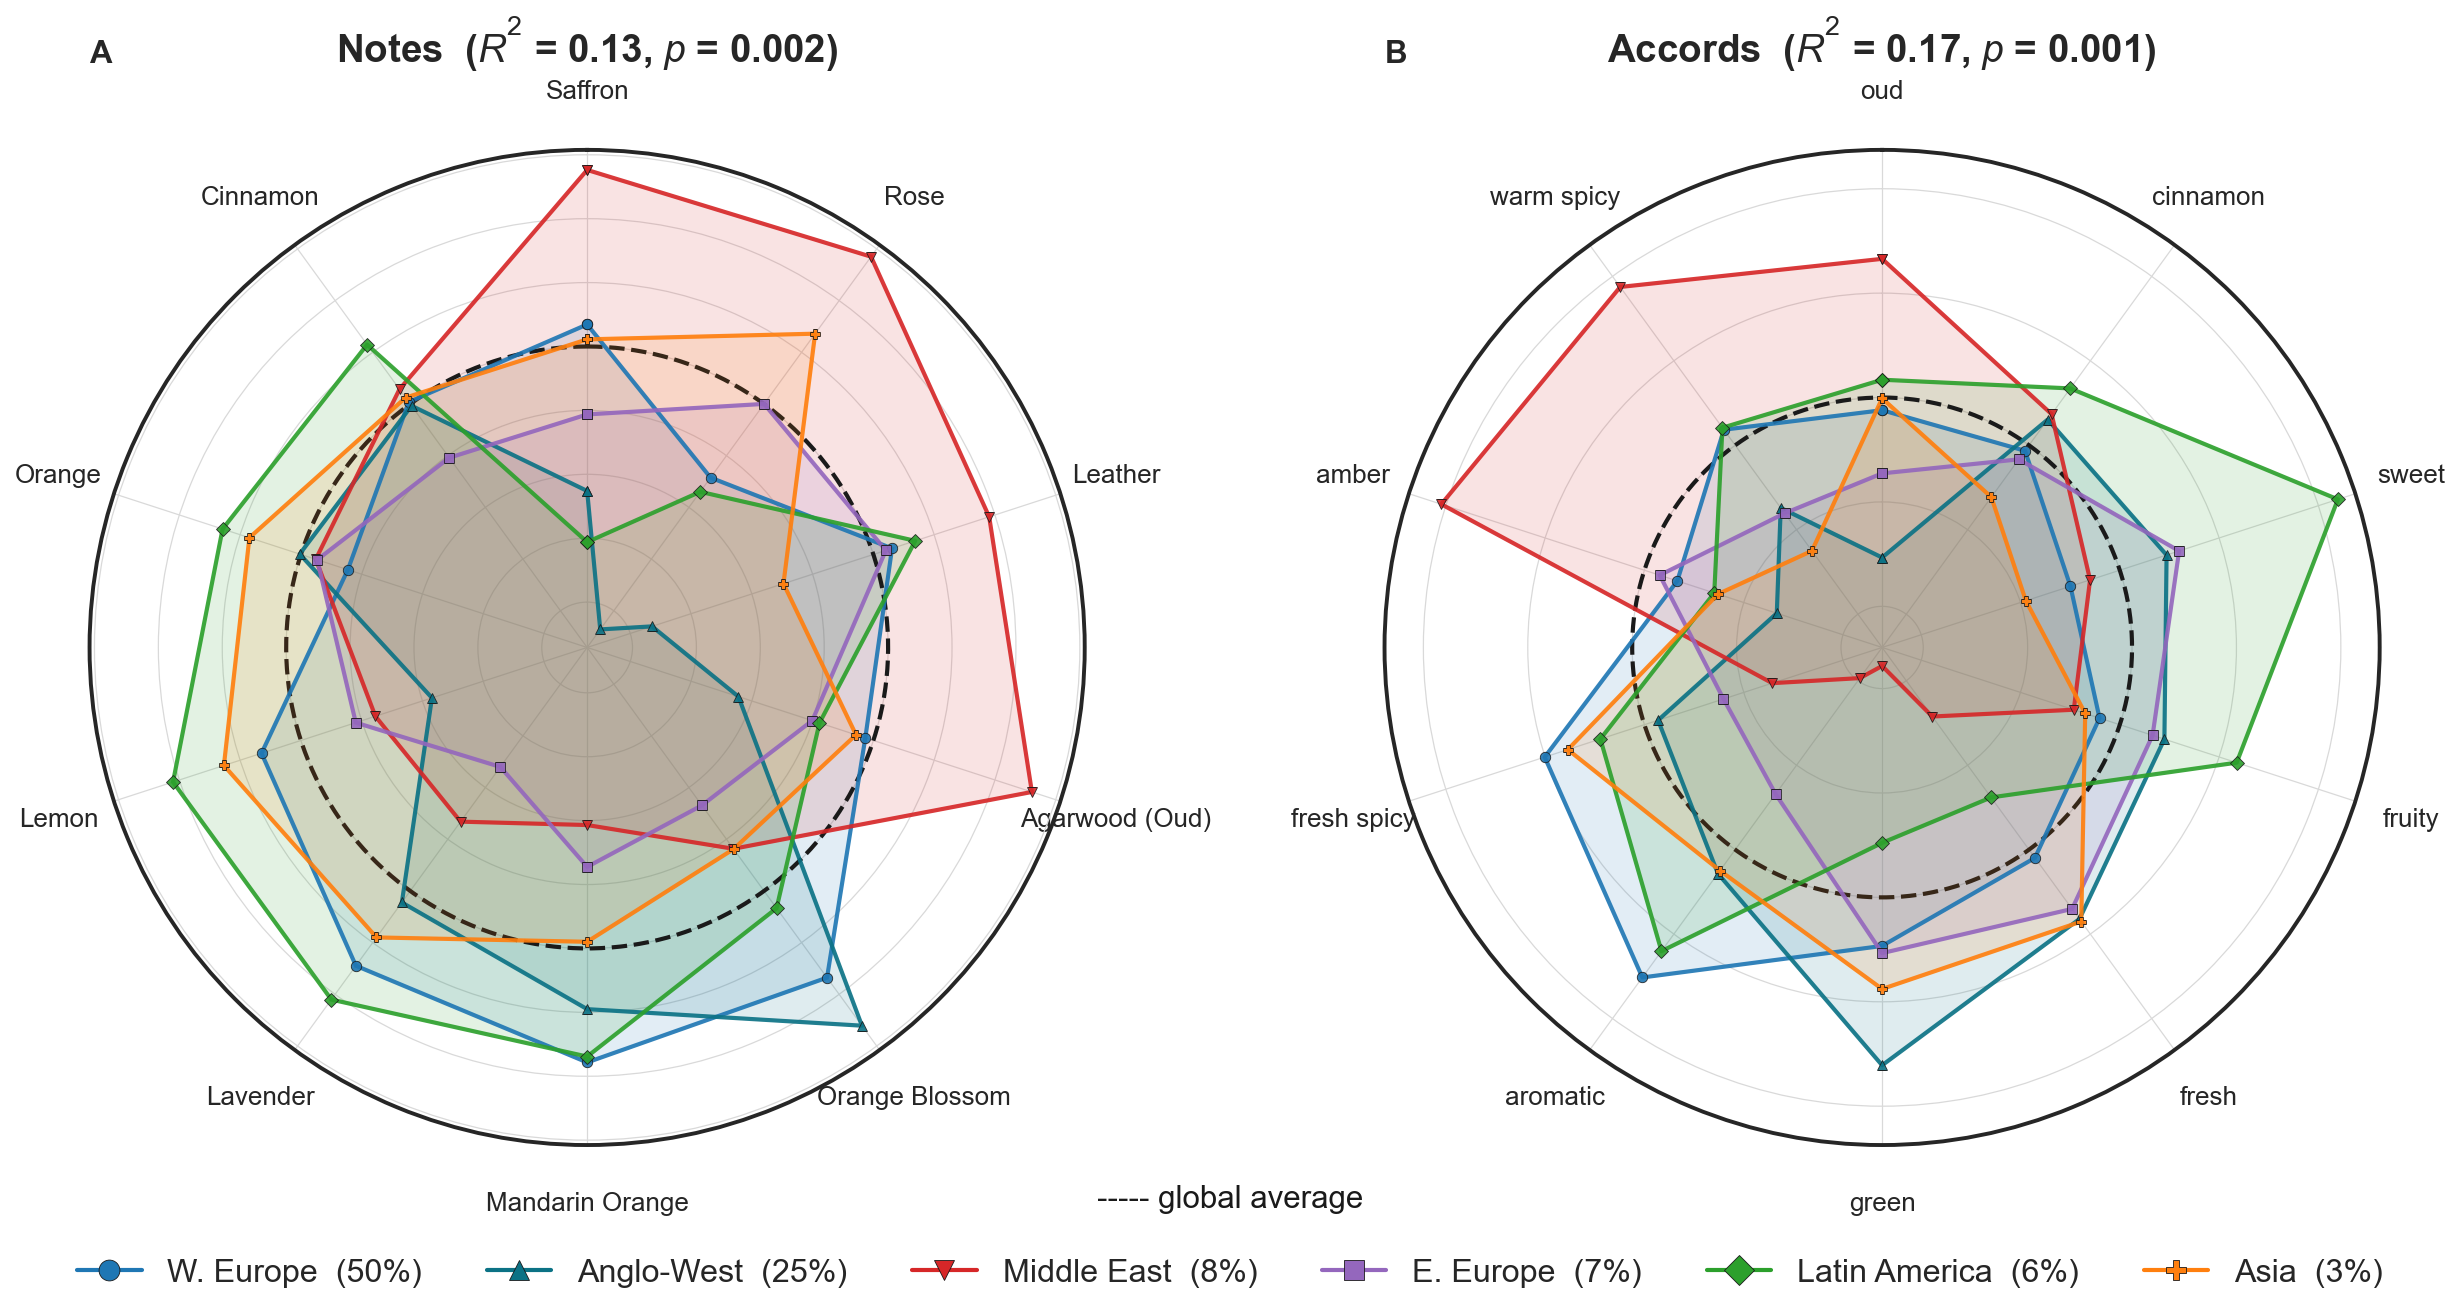

In [22]:
from collections import defaultdict
from sklearn.decomposition import PCA

_MINP, _NF = 30, 40
_cmap = {"United States": "United States of America", "St. Barts": "St-Barthélemy",
         "United kingdom": "United Kingdom", "Dubai": "United Arab Emirates",
         "Moldavia": "Moldova", "Tenerife": "Spain", "Dominican Republic": "Dominican Rep.",
         "Czech Republic": "Czechia", "Tahiti": "Fr. Polynesia", "Wales": "United Kingdom"}
_geo = data.copy()
_geo["Country"] = _geo["Country"].replace(_cmap)

GEO_REGION = {**{c: 'W. Europe' for c in ['Austria', 'Belgium', 'Denmark', 'France', 'Germany', 'Ireland',
        'Italy', 'Netherlands', 'Norway', 'Portugal', 'Spain', 'Sweden', 'Switzerland', 'United Kingdom', 'Monaco']},
    **{c: 'E. Europe' for c in ['Belarus', 'Bulgaria', 'Croatia', 'Czechia', 'Hungary', 'Latvia',
        'Lithuania', 'Poland', 'Romania', 'Russia', 'Ukraine', 'Greece']},
    **{c: 'Anglo-West' for c in ['United States of America', 'Canada', 'Australia', 'New Zealand', 'Bermuda']},
    **{c: 'Latin America' for c in ['Argentina', 'Brazil', 'Chile', 'Colombia', 'Mexico', 'Peru']},
    **{c: 'Middle East' for c in ['Egypt', 'Morocco', 'Turkey', 'Iran', 'Saudi Arabia', 'United Arab Emirates',
        'Kuwait', 'Qatar', 'Bahrain', 'Oman', 'Israel', 'Armenia', 'Azerbaijan']},
    **{c: 'Asia' for c in ['India', 'Pakistan', 'China', 'Japan', 'South Korea', 'Hong Kong',
        'Indonesia', 'Malaysia', 'Philippines', 'Singapore', 'Thailand', 'Vietnam']}}
GEO_EDGE = {'W. Europe': '#1f77b4', 'E. Europe': '#9467bd', 'Anglo-West': '#0b7285',
            'Latin America': '#2ca02c', 'Middle East': '#d62728', 'Asia': '#ff7f0e', 'Other': '#555555'}
GEO_MARK = {'W. Europe': 'o', 'E. Europe': 's', 'Anglo-West': '^',
            'Latin America': 'D', 'Middle East': 'v', 'Asia': 'P', 'Other': 'X'}
GEO_REGS = ['W. Europe', 'Anglo-West', 'Middle East', 'E. Europe', 'Latin America', 'Asia']

_grng = np.random.RandomState(0)
def _permanova(X, lab, perms=999):
    """One-way PERMANOVA -> raw pseudo-R^2, permutation p, pseudo-F, group-count-adjusted R^2."""
    m = lab != None; X = X[m]; lab = lab[m].astype(str)
    n = len(lab); k = len(set(lab))
    sst = ((X - X.mean(0)) ** 2).sum()
    ssw = lambda l: sum(((X[l == gg] - X[l == gg].mean(0)) ** 2).sum() for gg in set(l))
    r2 = 1 - ssw(lab) / sst
    F = (r2 / (k - 1)) / ((1 - r2) / (n - k))
    adj = 1 - (1 - r2) * (n - 1) / (n - k)
    cnt = sum(1 for _ in range(perms) if 1 - ssw(lab[_grng.permutation(n)]) / sst >= r2)
    return r2, (cnt + 1) / (perms + 1), F, adj

def _build(series):
    """Region-mean z-scored log-LQ profile + PERMANOVA for a parsed item column (accords or notes)."""
    prof = defaultdict(lambda: defaultdict(float)); ncty = defaultdict(int); g = defaultdict(float)
    for c, a in zip(_geo['Country'], series):
        if pd.isna(c):
            continue
        ncty[c] += 1
        for x in a:
            prof[c][x] += 1; g[x] += 1
    cs = sorted(c for c in prof if ncty[c] >= _MINP)
    feat = [a for a, _ in sorted(g.items(), key=lambda x: -x[1])[:_NF]]
    gt = sum(g.values()); gs = {a: g[a] / gt for a in feat}; EPS = 1e-4
    M = np.zeros((len(cs), len(feat)))
    for i, c in enumerate(cs):
        s = sum(prof[c].values())
        for j, a in enumerate(feat):
            M[i, j] = np.log((prof[c].get(a, 0) / s + EPS) / (gs[a] + EPS))
    Mz = (M - M.mean(0)) / (M.std(0) + 1e-9)
    reg = np.array([GEO_REGION.get(c, 'Other') for c in cs], dtype=object)
    frac = np.array([ncty[c] for c in cs], float); frac /= frac.sum()
    share = {r: frac[reg == r].sum() for r in GEO_REGS}
    rmean = {r: Mz[reg == r].mean(0) for r in GEO_REGS}
    pca = PCA(n_components=2).fit(Mz)
    load = np.hypot(pca.components_[0], pca.components_[1])
    idx = list(np.argsort(-load)[:10])
    th = np.arctan2(pca.components_[1], pca.components_[0])
    idx = sorted(idx, key=lambda j: th[j])
    r2, p, F, adj = _permanova(Mz, np.where(reg == 'Other', None, reg))
    return dict(names=[feat[j] for j in idx], idx=idx, rmean=rmean, share=share,
                RM=np.array([rmean[r] for r in GEO_REGS]), r2=r2, p=p, F=F, adj=adj)

geo_A = _build(_geo['accords'].apply(parse_accords))
geo_B = _build(_geo['notes'].apply(parse_notes))
print(f"Accords: region explains {geo_A['r2']*100:.0f}% of profile variance "
      f"(raw R^2={geo_A['r2']:.3f}, adj R^2={geo_A['adj']:.3f}, pseudo-F={geo_A['F']:.2f}, p={geo_A['p']:.3f}).")
print(f"Notes:   region explains {geo_B['r2']*100:.0f}% of profile variance "
      f"(raw R^2={geo_B['r2']:.3f}, adj R^2={geo_B['adj']:.3f}, pseudo-F={geo_B['F']:.2f}, p={geo_B['p']:.3f}).")

def _draw(ax, D, letter, title):
    names, idx, rmean, share, RM = D['names'], D['idx'], D['rmean'], D['share'], D['RM']
    ang = np.linspace(0, 2 * np.pi, len(names), endpoint=False).tolist(); ang += ang[:1]
    ax.set_theta_offset(np.pi / 2); ax.set_theta_direction(-1)
    lo, hi = RM[:, idx].min(), RM[:, idx].max()
    ax.plot(np.linspace(0, 2 * np.pi, 200), [0] * 200, color='k', lw=2.0, ls='--', zorder=7)
    for z, r in enumerate(sorted(GEO_REGS, key=lambda r: -share[r])):
        v = [rmean[r][j] for j in idx]; v += v[:1]
        ax.fill(ang, v, color=GEO_EDGE[r], alpha=0.13, zorder=2 + z)
        ax.plot(ang, v, color=GEO_EDGE[r], lw=2.0, alpha=0.9, marker=GEO_MARK[r], ms=5,
                markeredgecolor='k', markeredgewidth=0.4, zorder=10 + z)
    ax.set_xticks(ang[:-1]); ax.set_xticklabels(names, fontsize=12.5); ax.tick_params(axis='x', pad=12)
    ax.set_ylim(lo * 1.08, hi * 1.08); ax.set_yticklabels([]); ax.grid(color='0.85', lw=0.6)
    ax.set_title(letter, loc='left', fontsize=15, fontweight='bold', pad=18)
    ax.set_title(f'{title}  ($R^2$ = {D["r2"]:.2f}, $p$ = {D["p"]:.3f})',
                 loc='center', fontsize=18.5, fontweight='bold', pad=8)

fig = plt.figure(figsize=(17, 8.5))
ax1 = fig.add_subplot(1, 2, 1, polar=True)
ax2 = fig.add_subplot(1, 2, 2, polar=True)
_draw(ax1, geo_B, 'A', 'Notes')
_draw(ax2, geo_A, 'B', 'Accords')
_hand = [mlines.Line2D([], [], marker=GEO_MARK[r], color=GEO_EDGE[r], lw=2, ms=10,
         markeredgecolor='k', markeredgewidth=0.4, label=f'{r}  ({geo_A["share"][r]*100:.0f}%)') for r in GEO_REGS]
fig.legend(handles=_hand, loc='lower center', ncol=6, fontsize=15.5, frameon=False,
           bbox_to_anchor=(0.5, -0.02), title='', title_fontsize=15)
fig.text(0.5, 0.065, '----- global average',
         ha='center', fontsize=15, color='k')
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig("../output/Figure_S3.pdf", format="pdf", dpi=300, bbox_inches='tight')
plt.show()

### Figure S4: Gender Coding of Notes and Accords Over Time

Net of the unisex surge: female-vs-male balance among gendered perfumes only, (women - men) / (women + men), compared between an early and a recent window. Per-item 2x2 chi-square with Benjamini-Hochberg FDR; stars mark materials whose balance crosses the neutral line.

Items tested: notes 95 (38 significant at q<.05), accords 38 (21 significant at q<.05)
--- net male<->female change (FDR-significant items) ---
Notes: of 38 significant, 22 drift toward masculine vs 16 toward feminine (net 6 masculine); sign crossings female->male 5, male->female 2 (net 3 female->male); mean shift d = -0.049
Accords: of 21 significant, 14 drift toward masculine vs 7 toward feminine (net 7 masculine); sign crossings female->male 3, male->female 1 (net 2 female->male); mean shift d = -0.067
Combined sign crossings: female->male 8, male->female 3
  (anchor) Tuberose: +0.98 -> +0.93
  (anchor) Rose: +0.66 -> +0.77
  (anchor) Ylang-Ylang: +0.89 -> +0.85
  (anchor) Tobacco: -0.69 -> -0.64


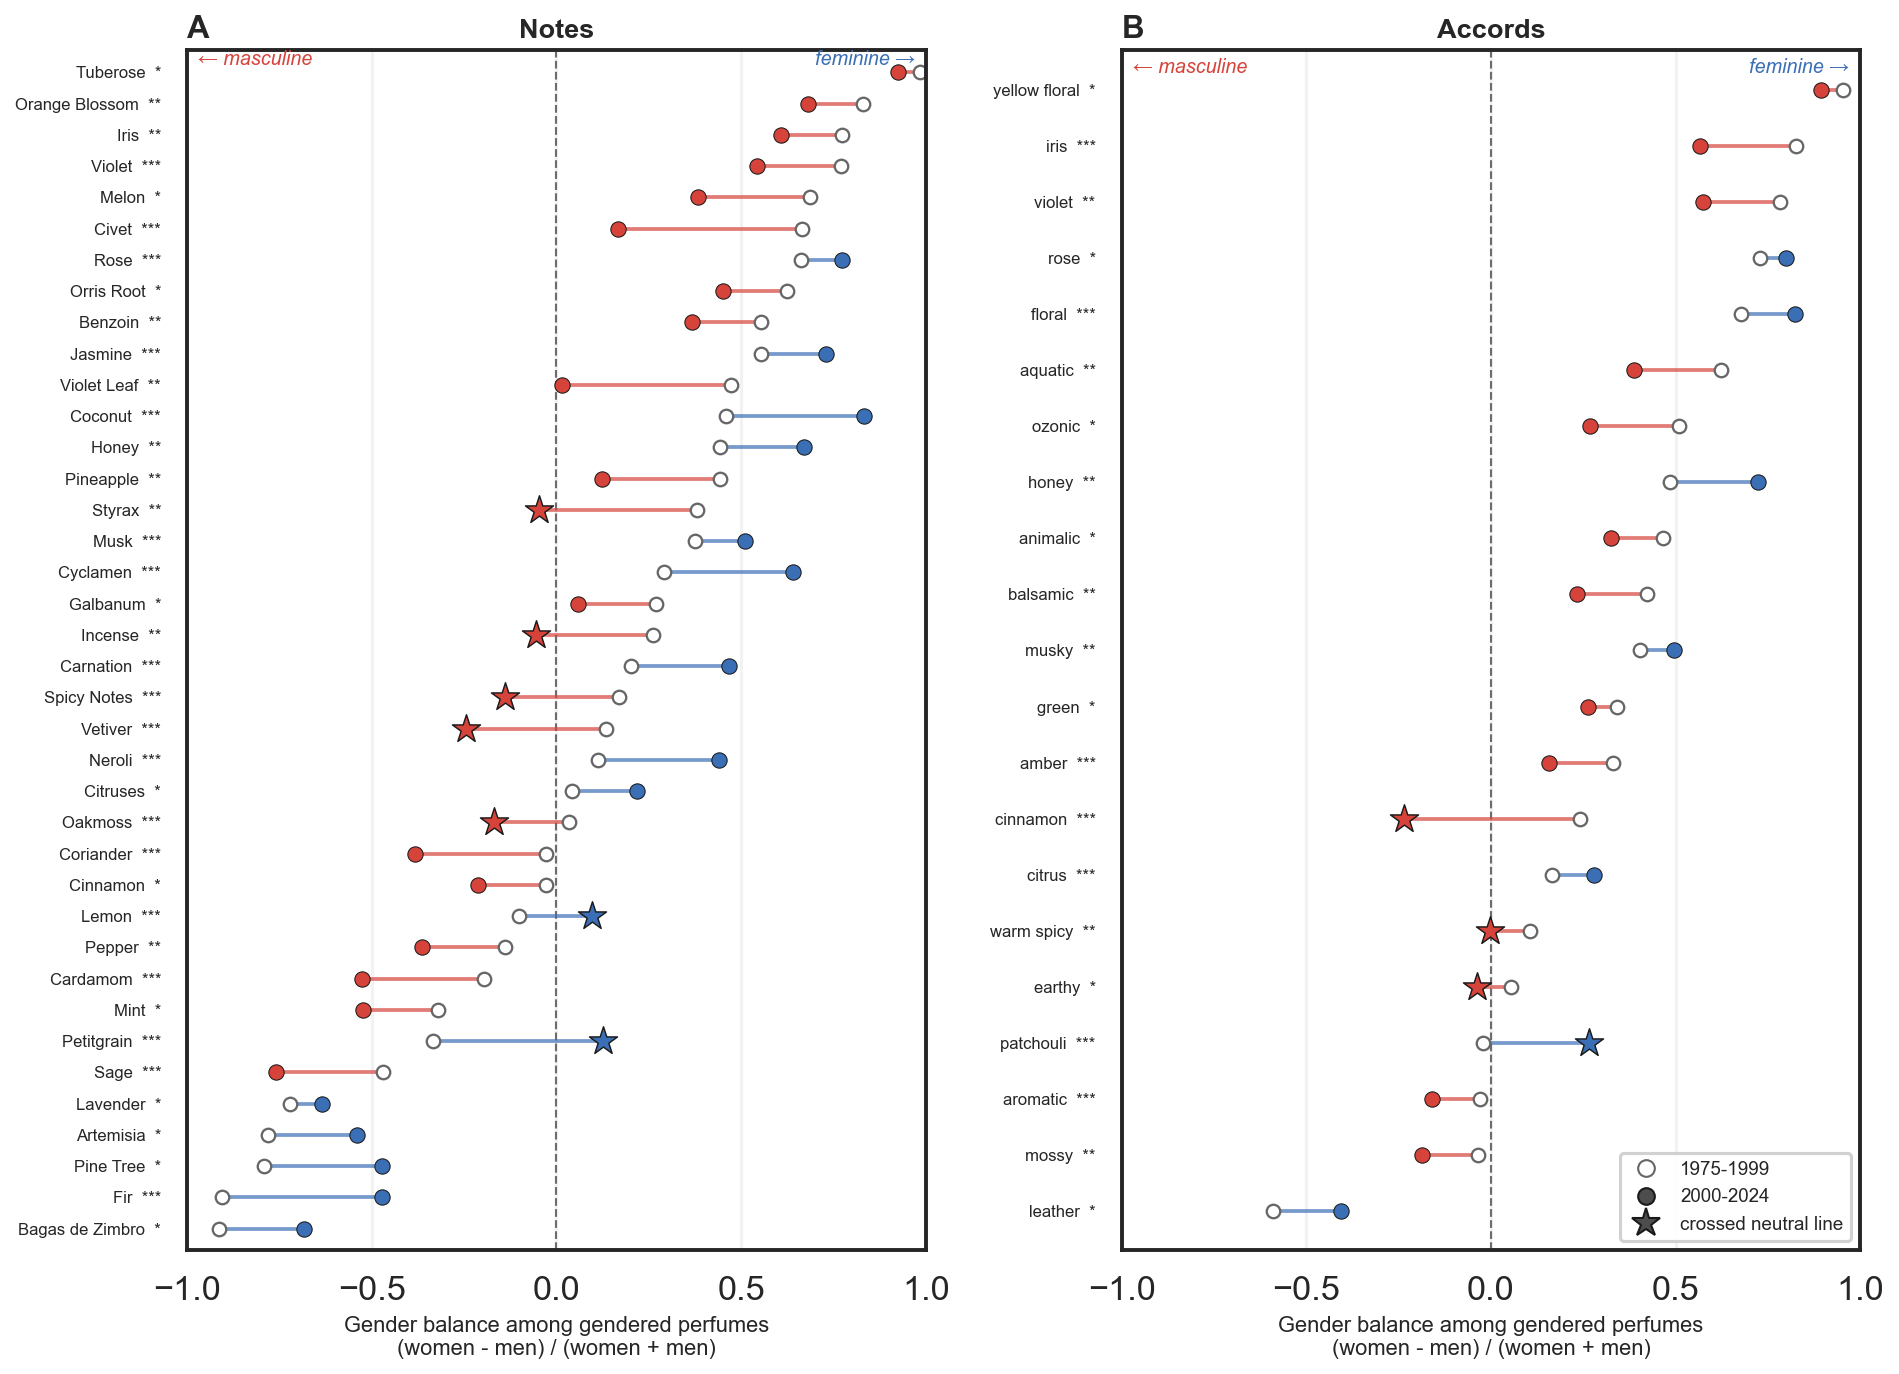

In [23]:
from collections import Counter
from scipy.stats import chi2_contingency

_glab = {'male': 'M', 'men': 'M', 'm': 'M', 'female': 'F', 'women': 'F', 'f': 'F',
         'unisex': 'U', 'shared': 'U'}
gdf = data.copy()
gdf['g'] = gdf['gender'].str.lower().map(_glab)
gdf = gdf[gdf['g'].notna()]
gdf['notes_l'] = gdf['notes'].apply(parse_notes)
gdf['acc_l']   = gdf['accords'].apply(parse_accords)
EARLY  = gdf[(gdf['year'] >= 1975) & (gdf['year'] <= 1999)]
RECENT = gdf[(gdf['year'] >= 2000) & (gdf['year'] <= 2024)]
MIN_G  = 40

def _bh(p):
    """Benjamini-Hochberg FDR-adjusted q-values."""
    p = np.asarray(p, float); n = len(p); order = np.argsort(p)
    q = np.empty(n); prev = 1.0
    for rank in range(n - 1, -1, -1):
        i = order[rank]; prev = min(prev, p[i] * n / (rank + 1)); q[i] = prev
    return q

def _gender_balance(col, universe):
    """Female-vs-male balance among gendered perfumes only, early vs recent, with a 2x2 chi-square per item."""
    rows = []
    for it in universe:
        ge = EARLY [EARLY [col].apply(lambda L: it in L)]['g']
        gr = RECENT[RECENT[col].apply(lambda L: it in L)]['g']
        ge = ge[ge != 'U']; gr = gr[gr != 'U']
        if len(ge) < MIN_G or len(gr) < MIN_G:
            continue
        fe = ((ge == 'F').sum() - (ge == 'M').sum()) / len(ge)
        fr = ((gr == 'F').sum() - (gr == 'M').sum()) / len(gr)
        try:
            p = chi2_contingency(np.array([[(ge == 'F').sum(), (ge == 'M').sum()],
                                           [(gr == 'F').sum(), (gr == 'M').sum()]]))[1]
        except Exception:
            p = 1.0
        rows.append((it, fe, fr, fr - fe, len(gr), p))
    df = pd.DataFrame(rows, columns=['item', 'fe', 'fr', 'd', 'n_r', 'p'])
    df['q'] = _bh(df['p'].values)
    return df

_ncnt = Counter(x for L in gdf['notes_l'] for x in L)
_acnt = Counter(x for L in gdf['acc_l'] for x in L)
N_tab = _gender_balance('notes_l', [k for k, _ in _ncnt.most_common(120)])
A_tab = _gender_balance('acc_l',   [k for k, _ in _acnt.most_common(45)])

print(f'Items tested: notes {len(N_tab)} ({(N_tab["q"]<.05).sum()} significant at q<.05), '
      f'accords {len(A_tab)} ({(A_tab["q"]<.05).sum()} significant at q<.05)')

# Net directional change: materials moving toward men vs women
def _net_change(df, label):
    s = df[df['q'] < 0.05]
    to_f = int((s['d'] > 0).sum()); to_m = int((s['d'] < 0).sum())
    f2m  = int(((s['fe'] > 0) & (s['fr'] < 0)).sum())
    m2f  = int(((s['fe'] < 0) & (s['fr'] > 0)).sum())
    print(f'{label}: of {len(s)} significant, {to_m} drift toward masculine vs {to_f} toward feminine '
          f'(net {to_m - to_f} masculine); sign crossings female->male {f2m}, male->female {m2f} '
          f'(net {f2m - m2f} female->male); mean shift d = {s["d"].mean():+.3f}')
    return f2m, m2f
print('--- net male<->female change (FDR-significant items) ---')
_nf2m, _nm2f = _net_change(N_tab, 'Notes')
_af2m, _am2f = _net_change(A_tab, 'Accords')
print(f'Combined sign crossings: female->male {_nf2m + _af2m}, male->female {_nm2f + _am2f}')

# Anchors
for _anchor in ['Tuberose', 'Rose', 'Ylang-Ylang', 'Tobacco']:
    _r = N_tab[N_tab['item'] == _anchor]
    if len(_r):
        print(f'  (anchor) {_anchor}: {_r.fe.iloc[0]:+.2f} -> {_r.fr.iloc[0]:+.2f}')

N_tab = N_tab[N_tab['q'] < 0.05].sort_values('fe')
A_tab = A_tab[A_tab['q'] < 0.05].sort_values('fe')

def _sig(q):
    return '***' if q < 1e-3 else '**' if q < 1e-2 else '*' if q < 0.05 else 'n.s.'

def _dumbbell(ax, df, letter, title):
    for i, (_, r) in enumerate(df.iterrows()):
        crossed = np.sign(r['fe']) != np.sign(r['fr'])
        col = '#d6433b' if r['d'] < 0 else '#3b6fb5'
        ax.plot([r['fe'], r['fr']], [i, i], color=col, lw=1.8, alpha=0.7, zorder=1)
        ax.scatter(r['fe'], i, s=42, facecolor='white', edgecolor='0.4', linewidths=1.1, zorder=2)
        if crossed:
            ax.scatter(r['fr'], i, marker='*', s=200, facecolor=col, edgecolor='k', linewidths=0.7, zorder=4)
        else:
            ax.scatter(r['fr'], i, s=54, facecolor=col, edgecolor='k', linewidths=0.5, zorder=3)
    ax.axvline(0, color='0.3', lw=1.0, ls='--', zorder=0)
    ax.set_yticks(range(len(df)))
    ax.set_yticklabels([f'{r.item}  {_sig(r.q)}' for r in df.itertuples()], fontsize=8)
    ax.set_ylim(-0.7, len(df) - 0.3); ax.set_xlim(-1, 1)
    ax.set_xlabel('Gender balance among gendered perfumes\n(women - men) / (women + men)', fontsize=10.5)
    ax.set_title(letter, loc='left', fontsize=15, fontweight='bold')
    ax.set_title(title, loc='center', fontsize=13, fontweight='bold')
    ax.text(-0.97, len(df) - 0.6, '← masculine', fontsize=9.5, color='#d6433b',
            ha='left', va='center', style='italic')
    ax.text(0.97, len(df) - 0.6, 'feminine →', fontsize=9.5, color='#3b6fb5',
            ha='right', va='center', style='italic')
    ax.grid(axis='x', alpha=0.25)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 9.5))
_dumbbell(ax1, N_tab, 'A', 'Notes')
_dumbbell(ax2, A_tab, 'B', 'Accords')
_leg = [mlines.Line2D([], [], marker='o', ls='None', mfc='white', mec='0.4', ms=8, label='1975-1999'),
        mlines.Line2D([], [], marker='o', ls='None', mfc='0.3', mec='k', ms=8, label='2000-2024'),
        mlines.Line2D([], [], marker='*', ls='None', mfc='0.3', mec='k', ms=14, label='crossed neutral line')]
ax2.legend(handles=_leg, loc='lower right', fontsize=9, frameon=True, framealpha=0.9)
plt.tight_layout()
plt.savefig("../output/Figure_S4.PDF", format="PDF", dpi=300, bbox_inches='tight')
plt.show()